# Notebook 16 — Semantic 3-D Mapping

**Vision & 3D Mapping Workshop** | Block 6: Semantic Understanding

---

## Why This Matters

Geometry alone tells you there's a surface 3 metres ahead. Semantic understanding
tells you it's a *tree* vs a *wall* vs a *person*. For a drone, this distinction
determines behaviour: you fly over a bush but around a building.

In this notebook we bridge **2-D image understanding** with **3-D scene
reconstruction**. The central idea is deceptively simple: if we can assign a
semantic class label to every pixel in an image, and we know the depth at
every pixel, we can back-project those labels into 3-D space and accumulate
them over multiple views to build a *semantically annotated* 3-D map.

### What You'll Learn

- How semantic segmentation assigns per-pixel class labels using deep networks (FCN, DeepLab, SAM 2)
- Back-projecting 2-D labels into 3-D to create semantic point clouds from RGB-D frames
- Bayesian label fusion in a Semantic TSDF volume using log-odds accumulation across views
- Open-vocabulary 3-D understanding (LERF, OpenScene, MPEC): querying maps with natural language via CLIP embeddings
- Multi-camera BEV perception (LSS, BEVFormer): the surround-view approach used in autonomous driving
- Panoptic mapping: unifying stuff (road, sky) and things (cars, people) with instance IDs in 3-D
- 3-D scene graphs: adding relational structure (ON, NEXT_TO, INSIDE) for higher-level reasoning and language-guided navigation

**Roadmap**

| Section | Topic | Code? |
|---------|-------|-------|
| 1 | Semantic segmentation fundamentals | Yes |
| 2 | Lifting 2-D labels to 3-D point clouds | Yes |
| 3 | Semantic TSDF (Bayesian label fusion, log-odds) | Yes |
| 4 | Open-vocabulary 3-D (LERF, OpenScene, MPEC) | Yes |
| 5 | Multi-camera / BEV perception (LSS, BEVFormer) | Discussion |
| 6 | Panoptic mapping | Discussion |
| 6b | 3-D Scene Graphs | Yes |
| 7 | Exercises | Yes |

In [1]:
import sys
sys.path.insert(0, "..")

%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from src.pointcloud import depth_to_pointcloud
from src.semantic import SemanticTSDF
from src.camera import CameraIntrinsics

np.random.seed(42)

---
## 1  Semantic Segmentation

### 1.1  Goal

Semantic segmentation assigns a **class label** $k \in \{1,\dots,C\}$ to
*every* pixel $(u,v)$ in an image.  Unlike object detection (bounding boxes)
or classification (single label per image), the output is a dense
**label map** $L \in \mathbb{Z}^{H \times W}$ with the same spatial
resolution as the input.

### 1.2  Network architectures

#### Fully Convolutional Networks (FCN)

Long et al. (2015) replaced the fully-connected classification layers of
AlexNet / VGG with $1\times1$ convolutions, producing a spatial output.  Skip
connections from earlier layers (FCN-8s) recover fine-grained detail lost
during pooling.

#### DeepLab and Atrous (Dilated) Convolutions

Standard convolutions with stride > 1 reduce resolution.  **Atrous
(dilated) convolutions** insert zeros between filter weights, enlarging the
receptive field without losing spatial resolution.

A dilated convolution with rate $r$ on a 1-D signal $x$ with filter $w$ of
size $K$ is defined as:

$$
(x *_r w)[n] = \sum_{k=0}^{K-1} w[k]\; x[n - r \cdot k]
$$

The effective receptive field grows as $r(K-1)+1$ while the number of
parameters stays at $K$.  DeepLab stacks multiple rates in its **Atrous
Spatial Pyramid Pooling (ASPP)** module, capturing context at several
scales simultaneously.

#### SAM 2 (Segment Anything Model 2)

SAM 2 (Ravi et al., 2024) extends SAM to video, using a *memory attention*
mechanism that propagates mask predictions across frames.  It is
prompt-driven (points, boxes, or masks) rather than class-driven, so it is
typically paired with a classifier for semantic labelling.

### 1.3  Per-pixel cross-entropy loss

Let $y_{ik}$ be the one-hot ground-truth indicator for pixel $i$ and class
$k$, and let $\hat{p}_{ik}$ be the predicted probability.  The per-pixel
cross-entropy loss averaged over $N$ pixels and $C$ classes is:

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}\sum_{k=1}^{C}
    y_{ik}\log(\hat{p}_{ik})
$$

Because exactly one $y_{ik}=1$ per pixel, this simplifies to:

$$
\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N}
    \log\bigl(\hat{p}_{i,\,y_i^*}\bigr)
$$

where $y_i^*$ is the true class of pixel $i$.

**Softmax.** The network's raw output is a logit vector
$\mathbf{z}_i \in \mathbb{R}^C$ per pixel.  Probabilities are obtained
via the softmax function:

$$
\hat{p}_{ik} = \frac{\exp(z_{ik})}{\sum_{k'=1}^{C}\exp(z_{ik'})}
$$

Substituting into the loss and using $y_i^* = \arg\max_k y_{ik}$:

$$
\mathcal{L}
= -\frac{1}{N}\sum_{i=1}^{N}\Bigl[
    z_{i,y_i^*}
    - \log\sum_{k'=1}^{C}\exp(z_{ik'})
  \Bigr]
$$

This is the *log-sum-exp* form used in practice for numerical stability.

**Class-weighted cross-entropy.** Semantic segmentation datasets are
heavily imbalanced (e.g. "road" dominates, "person" is rare).  A per-class
weight $w_k > 0$ rebalances the loss:

$$
\mathcal{L}_w
= -\frac{1}{N}\sum_{i=1}^{N} w_{y_i^*}\,
    \log\bigl(\hat{p}_{i,\,y_i^*}\bigr)
$$

A common choice is **inverse-frequency weighting**:

$$
w_k = \frac{N}{\,C \cdot n_k\,}
$$

where $n_k = |\{i : y_i^* = k\}|$ is the number of pixels of class $k$.
Rare classes receive higher weight, ensuring the network does not simply
predict the majority class everywhere.

### 1.4  Intersection over Union (IoU)

For class $k$, let $P_k$ be the set of pixels *predicted* as $k$ and $G_k$
the set of *ground-truth* pixels of class $k$.  Then:

$$
\text{IoU}_k = \frac{|P_k \cap G_k|}{|P_k \cup G_k|}
$$

**Connection to the confusion matrix.**  Define TP (true positives),
FP (false positives), and FN (false negatives) for class $k$:

$$
\text{TP}_k = |P_k \cap G_k|, \quad
\text{FP}_k = |P_k \setminus G_k|, \quad
\text{FN}_k = |G_k \setminus P_k|
$$

Since $|P_k \cup G_k| = \text{TP}_k + \text{FP}_k + \text{FN}_k$,
IoU can equivalently be written as:

$$
\text{IoU}_k = \frac{\text{TP}_k}{\text{TP}_k + \text{FP}_k + \text{FN}_k}
$$

This is also called the **Jaccard index**.  Unlike accuracy, it is not
inflated by true negatives and is therefore robust to class imbalance.

The **mean IoU** (mIoU) is:

$$
\text{mIoU} = \frac{1}{C}\sum_{k=1}^{C} \text{IoU}_k
$$

mIoU is the standard metric on benchmarks such as PASCAL VOC and
Cityscapes.

In [2]:
# -- 1.5  Define semantic classes and colour palette --

CLASS_NAMES = ["ground", "building", "vegetation", "sky", "vehicle", "person"]
NUM_CLASSES = len(CLASS_NAMES)

CLASS_COLORS = np.array([
    [128, 128, 128],   # ground     - grey
    [180,  60,  60],   # building   - brick red
    [ 50, 160,  50],   # vegetation - green
    [135, 206, 250],   # sky        - light blue
    [ 30,  30, 200],   # vehicle    - blue
    [220, 180,  50],   # person     - yellow
], dtype=np.uint8)

for i, (name, col) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    print(f"  {i}: {name:12s}  {tuple(col)}")

  0: ground        (np.uint8(128), np.uint8(128), np.uint8(128))
  1: building      (np.uint8(180), np.uint8(60), np.uint8(60))
  2: vegetation    (np.uint8(50), np.uint8(160), np.uint8(50))
  3: sky           (np.uint8(135), np.uint8(206), np.uint8(250))
  4: vehicle       (np.uint8(30), np.uint8(30), np.uint8(200))
  5: person        (np.uint8(220), np.uint8(180), np.uint8(50))


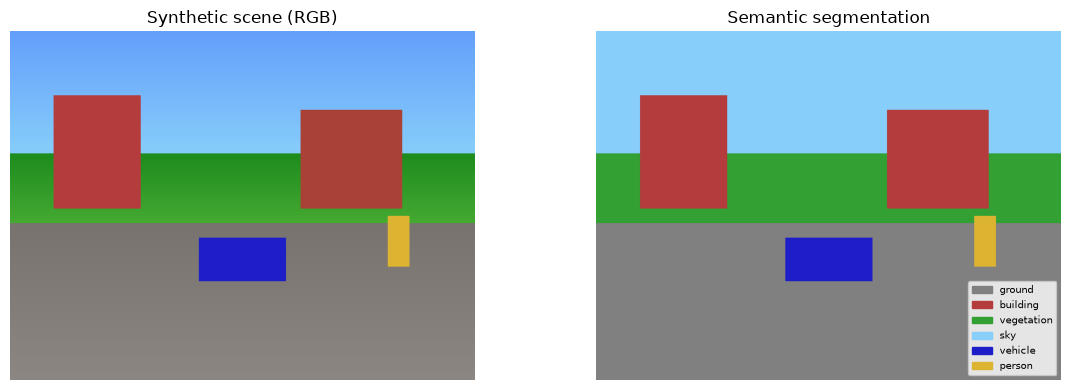

In [3]:
# -- 1.6  Synthesise a scene image --

H, W = 240, 320
image = np.zeros((H, W, 3), dtype=np.uint8)

# Sky - top 35 %
sky_end = int(0.35 * H)
for row in range(sky_end):
    t = row / sky_end
    image[row, :] = [int(100 + 35 * t), int(160 + 46 * t), 250]

# Vegetation band - next 20 %
veg_end = int(0.55 * H)
for row in range(sky_end, veg_end):
    t = (row - sky_end) / (veg_end - sky_end)
    image[row, :] = [int(30 + 40 * t), int(140 + 30 * t), int(30 + 20 * t)]

# Ground - bottom 45 %
for row in range(veg_end, H):
    t = (row - veg_end) / (H - veg_end)
    image[row, :] = [int(120 + 20 * t), int(115 + 20 * t), int(110 + 20 * t)]

# Building rectangles
image[sky_end-40:veg_end-10, 30:90]   = [180, 60, 60]
image[sky_end-30:veg_end-10, 200:270] = [170, 65, 55]

# Vehicle rectangle
image[veg_end+10:veg_end+40, 130:190] = [30, 30, 200]

# Person rectangle
image[veg_end-5:veg_end+30, 260:275]  = [220, 180, 50]

# -- Simple colour-threshold segmentation --

def simple_segment(img, sky_row, veg_row):
    """Threshold-based segmentation returning (H,W) int32 label map."""
    labels = np.zeros(img.shape[:2], dtype=np.int32)
    r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

    labels[:sky_row, :] = 3                          # sky
    labels[sky_row:veg_row, :] = 2                   # vegetation
    labels[veg_row:, :] = 0                          # ground

    bld_mask = (r > 140) & (g < 100) & (b < 100)
    labels[bld_mask] = 1                             # building

    veh_mask = (b > 150) & (r < 80) & (g < 80)
    labels[veh_mask] = 4                             # vehicle

    per_mask = (r > 180) & (g > 140) & (b < 100)
    labels[per_mask] = 5                             # person

    return labels

label_map = simple_segment(image, sky_end, veg_end)

# -- Build overlay --
overlay = CLASS_COLORS[label_map]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(image)
axes[0].set_title("Synthetic scene (RGB)")
axes[0].axis("off")

axes[1].imshow(overlay)
axes[1].set_title("Semantic segmentation")
axes[1].axis("off")

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
axes[1].legend(handles=patches, loc="lower right", fontsize=7)
plt.tight_layout()
plt.show()

---
## 2  Lifting 2-D Labels to 3-D

### 2.1  Back-projection

Given a calibrated camera with intrinsic matrix

$$
K = \begin{bmatrix}
    f_x & 0   & c_x \\
    0   & f_y & c_y \\
    0   & 0   & 1
\end{bmatrix},
$$

every pixel $(u,v)$ with measured depth $d > 0$ can be back-projected to a
3-D point $(X, Y, Z)$ in the camera frame:

$$
X = \frac{(u - c_x) \cdot d}{f_x}, \quad
Y = \frac{(v - c_y) \cdot d}{f_y}, \quad
Z = d
$$

In matrix form this is:

$$
\begin{pmatrix} X \\ Y \\ Z \end{pmatrix}
= d \; K^{-1}
\begin{pmatrix} u \\ v \\ 1 \end{pmatrix}
$$

### 2.2  Semantic point cloud

Each back-projected 3-D point inherits both the RGB colour and the
semantic class from its source pixel.  Formally, point $i$ is represented
as a 7-tuple:

$$
\mathbf{p}_i = \bigl(X_i,\; Y_i,\; Z_i,\; R_i,\; G_i,\; B_i,\;
    \text{class}_k\bigr)
$$

where $\text{class}_k \in \{0, \dots, C-1\}$.

This gives us a coloured and labelled 3-D point cloud from a single
RGB-D frame -- the fundamental building block for semantic 3-D mapping.

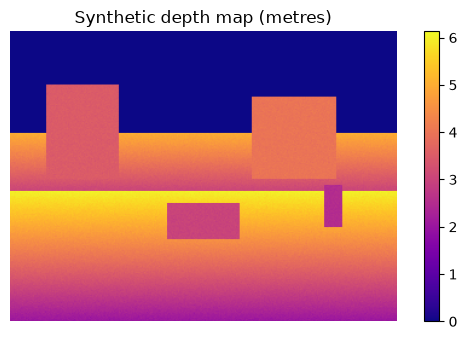

In [4]:
# -- 2.3  Generate synthetic depth map --

depth_map = np.zeros((H, W), dtype=np.float64)

# Sky has no valid depth (infinite) -> leave at 0
# Vegetation: 3-5 m
for row in range(sky_end, veg_end):
    t = (row - sky_end) / max(veg_end - sky_end, 1)
    depth_map[row, :] = 5.0 - 2.0 * t

# Ground: 2-6 m (closer at bottom)
for row in range(veg_end, H):
    t = (row - veg_end) / max(H - veg_end, 1)
    depth_map[row, :] = 6.0 - 4.0 * t

# Buildings are a bit closer than vegetation behind them
depth_map[sky_end-40:veg_end-10, 30:90]   = 3.5
depth_map[sky_end-30:veg_end-10, 200:270] = 4.0

# Vehicle
depth_map[veg_end+10:veg_end+40, 130:190] = 3.0

# Person
depth_map[veg_end-5:veg_end+30, 260:275]  = 2.5

# Add mild Gaussian noise
noise = np.random.normal(0, 0.05, depth_map.shape)
depth_map = np.where(depth_map > 0, depth_map + noise, 0.0)
depth_map = np.clip(depth_map, 0, None)

fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))
im = ax.imshow(depth_map, cmap="plasma")
ax.set_title("Synthetic depth map (metres)")
plt.colorbar(im, ax=ax, fraction=0.03)
ax.axis("off")
plt.tight_layout()
plt.show()

Point cloud: 54420 points
  ground      :  32310 points
  building    :   9440 points
  vegetation  :  10345 points
  sky         :      0 points
  vehicle     :   1800 points
  person      :    525 points


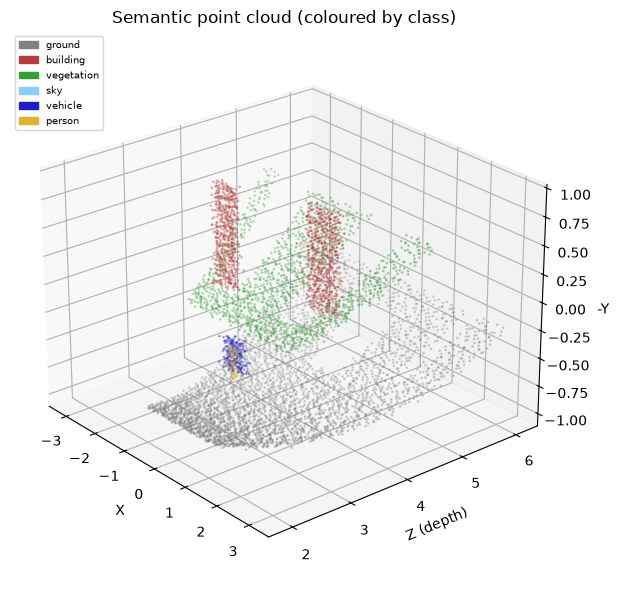

In [5]:
# -- 2.4  Back-project to a labelled + coloured point cloud --

cam = CameraIntrinsics(fx=300.0, fy=300.0, cx=W/2, cy=H/2)
K = cam.K

pts = depth_to_pointcloud(depth_map, K, color=image)
xyz = pts[:, :3]
rgb = pts[:, 3:6]

# Retrieve per-point labels from the label map
valid_mask = depth_map > 0
labels_flat = label_map[valid_mask]

print(f"Point cloud: {xyz.shape[0]} points")
for k in range(NUM_CLASSES):
    count = int(np.sum(labels_flat == k))
    print(f"  {CLASS_NAMES[k]:12s}: {count:>6d} points")

# -- Visualise (colour by class) --
colors_per_point = CLASS_COLORS[labels_flat] / 255.0

step = max(1, len(xyz) // 6000)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(
    xyz[::step, 0], xyz[::step, 2], -xyz[::step, 1],
    c=colors_per_point[::step], s=1, alpha=0.6,
)
ax.set_xlabel("X"); ax.set_ylabel("Z (depth)"); ax.set_zlabel("-Y")
ax.set_title("Semantic point cloud (coloured by class)")
ax.view_init(elev=25, azim=-40)

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
ax.legend(handles=patches, loc="upper left", fontsize=7)
plt.tight_layout()
plt.show()

---
## 3  Semantic TSDF

### 3.1  Extending the TSDF with class probabilities

A standard TSDF volume stores a signed-distance value $d_v$ and an
observation weight $w_v$ per voxel.  For semantic mapping, we augment each
voxel with a **probability distribution over $C$ classes**:

$$
\text{voxel } v \;\longrightarrow\;
\bigl(d_v,\; w_v,\; \boldsymbol{\ell}_v \in \mathbb{R}^C\bigr)
$$

where $\boldsymbol{\ell}_v$ is a vector of **log-probabilities** (logits).

### 3.2  Bayesian label fusion

We model successive observations $z_1, z_2, \dots, z_T$ as
**conditionally independent** given the true class.  By Bayes' rule the
posterior after $T$ observations factorises as:

$$
p(\text{class}_k \mid z_1, \ldots, z_T)
\;\propto\;
p(\text{class}_k)
\prod_{t=1}^{T} p(z_t \mid \text{class}_k)
\;\propto\;
\prod_{t=1}^{T} p_t(\text{class}_k)
$$

where in the last step we absorbed the prior into the first observation
term (uniform prior).

Taking logarithms turns the product into a sum:

$$
\log p(k \mid z_{1:T})
= \sum_{t=1}^{T} \log p_t(k) + \text{const}
$$

This is the key insight: **in log space, Bayesian fusion is a simple
accumulation**.  Each new observation just adds its log-likelihood to the
running sum.

### 3.3  Softmax normalisation

To recover proper probabilities from the accumulated log-probabilities
$\boldsymbol{\ell} = (\ell_1, \dots, \ell_C)$ we apply the softmax
function:

$$
p(k) = \frac{\exp(\ell_k)}{\sum_{k'=1}^{C} \exp(\ell_{k'})}
$$

For numerical stability, we subtract $\max_k \ell_k$ before
exponentiating (the normalisation constant cancels out).

### 3.4  Weighted geometry-semantics update

Each integration step updates both the TSDF geometry and the semantic
histogram.  For voxel $v$ observed in frame $t$:

$$
d_v \leftarrow
    \frac{w_v \, d_v^{\text{old}} + w_t \, d_v^{\text{new}}}
         {w_v + w_t}
$$

$$
\ell_{v,k} \leftarrow \ell_{v,k} + \log p_t(k \mid z_t)
$$

The geometry uses a weighted running average (Curless & Levoy 1996), while
the semantics use additive log-probability fusion (McCormac et al. 2017).

### 3.5  Recursive Bayesian update rule

The fusion from §3.2 is naturally recursive.  Given a new
observation $z_n$ and the posterior from the previous $n{-}1$
observations:

$$
P(c \mid z_1, \ldots, z_n)
\;\propto\; P(z_n \mid c)\; P(c \mid z_1, \ldots, z_{n-1})
$$

This is exactly Bayes' rule with the previous posterior serving as
the new prior.  No need to store all past observations — only the
current belief vector.

In **log-probability** form:

$$
\log P(c \mid z_{1:n})
= \log P(z_n \mid c) + \log P(c \mid z_{1:n-1}) - \log Z_n
$$

where $Z_n = \sum_{c'} P(z_n \mid c') P(c' \mid z_{1:n-1})$ is the
normalisation constant.  In practice we drop $\log Z_n$ (it is
class-independent) and normalise via softmax when probabilities are
needed.

For each voxel $v$, we maintain a **class belief vector**
$\boldsymbol{b}_v \in \mathbb{R}^C$ initialised to the uniform prior
$b_{v,k}^{(0)} = \frac{1}{C}$.  After integrating observation $z_n$:

$$
b_{v,k}^{(n)} = \frac{P(z_n \mid c{=}k)\; b_{v,k}^{(n-1)}}
                     {\sum_{k'=1}^{C} P(z_n \mid c{=}k')\; b_{v,k'}^{(n-1)}}
$$

In log space, this is the element-wise addition used in §3.4:

$$
\log b_{v,k}^{(n)} = \log b_{v,k}^{(n-1)} + \log P(z_n \mid c{=}k)
  \;-\; \text{LogSumExp}_{k'}
  \bigl[\log b_{v,k'}^{(n-1)} + \log P(z_n \mid c{=}k')\bigr]
$$

### 3.6  Log-odds formulation for efficient binary updates

For the special case of two classes (occupied / free, or
foreground / background), the **log-odds** representation is
particularly efficient.

Define the log-odds of class $c = 1$ as:

$$
l_v = \log \frac{P(c{=}1 \mid z_{1:n})}{P(c{=}0 \mid z_{1:n})}
$$

The recursive update becomes a simple addition:

$$
l_v^{(n)} = l_v^{(n-1)}
  + \underbrace{\log \frac{P(z_n \mid c{=}1)}{P(z_n \mid c{=}0)}}
    _{\text{inverse sensor model}}
  \;-\; l_0
$$

where $l_0 = \log \frac{P(c{=}1)}{P(c{=}0)}$ is the prior log-odds
(subtracted to avoid double-counting when the prior is already
embedded in $l_v^{(0)}$).

Recovering the probability from log-odds:

$$
P(c{=}1) = \frac{1}{1 + e^{-l_v}} = \sigma(l_v)
$$

**Multi-class extension.**  For $C$ classes, maintain a log-odds
vector $\boldsymbol{l}_v \in \mathbb{R}^{C-1}$ relative to a
reference class (e.g. class 0):

$$
l_{v,k} = \log \frac{P(c{=}k \mid z_{1:n})}{P(c{=}0 \mid z_{1:n})},
\qquad k = 1, \ldots, C{-}1
$$

The update for each component is still additive:

$$
l_{v,k}^{(n)} = l_{v,k}^{(n-1)}
  + \log \frac{P(z_n \mid c{=}k)}{P(z_n \mid c{=}0)}
$$

This is equivalent to the log-probability accumulation in §3.2 but
makes the connection to occupancy-grid mapping explicit and avoids
storing a full probability vector when only a binary decision is needed.

In [6]:
# -- 3.5  Create a SemanticTSDF volume and integrate synthetic frames --

vol_bounds = np.array([
    [-3.0, 3.0],
    [-2.0, 2.0],
    [ 0.5, 7.0],
])
voxel_size = 0.15

sem_tsdf = SemanticTSDF(
    vol_bounds=vol_bounds,
    voxel_size=voxel_size,
    num_classes=NUM_CLASSES,
    trunc_dist=0.45,
)

print(f"Volume dimensions: {sem_tsdf._dims}")
print(f"Total voxels:      {np.prod(sem_tsdf._dims)}")

# -- Generate 5 viewpoints (small lateral translations) --

def make_pose(tx, ty, tz):
    T = np.eye(4)
    T[0, 3] = tx
    T[1, 3] = ty
    T[2, 3] = tz
    return T

offsets = [
    ( 0.0,  0.0, 0.0),
    ( 0.3,  0.0, 0.1),
    (-0.3,  0.0, 0.1),
    ( 0.0,  0.2, -0.1),
    ( 0.15, -0.1, 0.2),
]

for i, (tx, ty, tz) in enumerate(offsets):
    T_c2w = make_pose(tx, ty, tz)
    noise_i = np.random.normal(0, 0.04, depth_map.shape)
    depth_noisy = np.where(depth_map > 0, depth_map + noise_i, 0.0)
    depth_noisy = np.clip(depth_noisy, 0, None)

    sem_tsdf.integrate(
        depth=depth_noisy,
        K=K,
        T=T_c2w,
        labels=label_map,
    )
    print(f"  Integrated frame {i} -- offset ({tx:.2f}, {ty:.2f}, {tz:.2f})")

Volume dimensions: (np.int32(40), np.int32(27), np.int32(44))
Total voxels:      47520
  Integrated frame 0 -- offset (0.00, 0.00, 0.00)
  Integrated frame 1 -- offset (0.30, 0.00, 0.10)
  Integrated frame 2 -- offset (-0.30, 0.00, 0.10)
  Integrated frame 3 -- offset (0.00, 0.20, -0.10)
  Integrated frame 4 -- offset (0.15, -0.10, 0.20)


Voxel label volume shape: (40, 27, 44)
Observed voxels:          9122 / 47520


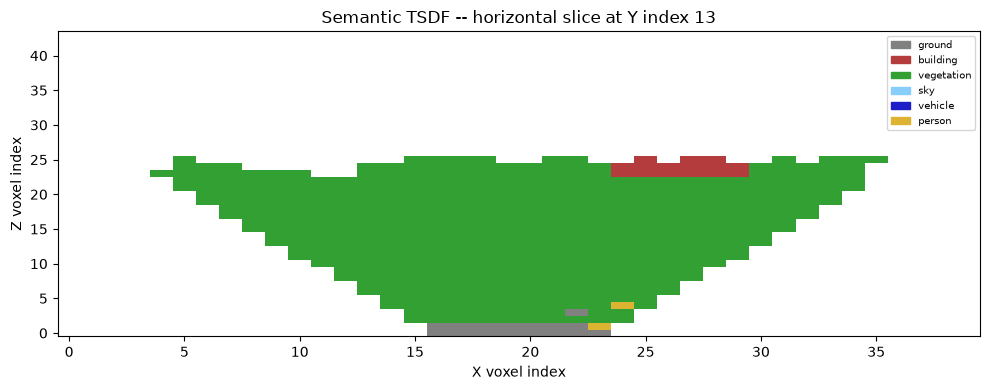

In [7]:
# -- 3.6  Extract voxel labels and visualise a 2-D slice --

voxel_labels = sem_tsdf.get_voxel_labels()
print(f"Voxel label volume shape: {voxel_labels.shape}")

observed_mask = sem_tsdf._weight > 0
print(f"Observed voxels:          {int(observed_mask.sum())} "
      f"/ {int(np.prod(voxel_labels.shape))}")

# Take a horizontal slice through the middle of the Y axis
y_mid = voxel_labels.shape[1] // 2
slice_labels = voxel_labels[:, y_mid, :]
slice_weight = sem_tsdf._weight[:, y_mid, :]

# Colour the slice: observed voxels by class, unobserved in white
slice_rgb = np.ones((*slice_labels.shape, 3), dtype=np.float64)
for k in range(NUM_CLASSES):
    mask = (slice_labels == k) & (slice_weight > 0)
    slice_rgb[mask] = CLASS_COLORS[k] / 255.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(slice_rgb.transpose(1, 0, 2), origin="lower", aspect="auto")
ax.set_xlabel("X voxel index")
ax.set_ylabel("Z voxel index")
ax.set_title(f"Semantic TSDF -- horizontal slice at Y index {y_mid}")

patches = [mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i])
           for i in range(NUM_CLASSES)]
ax.legend(handles=patches, loc="upper right", fontsize=7)
plt.tight_layout()
plt.show()

---
## 4  Open-Vocabulary 3-D Understanding (2024-2026 Frontier)

### 4.1  Limitations of closed-set segmentation

The methods in Sections 1-3 assign each pixel/voxel to one of a
*fixed* set of classes.  This limits flexibility: if we want to
find *fire hydrants* in a map trained on Cityscapes categories, we
are out of luck.

### 4.2  The idea: language-aligned 3-D features

The core idea behind open-vocabulary 3-D understanding is
conceptually elegant: **lift language-aligned features (CLIP,
DINOv2, SigLIP) into 3-D alongside geometry**.

For each 3-D point, store not just $(x, y, z, \text{color})$ but
also a **language-aligned feature vector** $\mathbf{f} \in
\mathbb{R}^d$:

$$
\mathbf{p}_i = \bigl(x_i,\; y_i,\; z_i,\; r_i,\; g_i,\; b_i,\;
\underbrace{\mathbf{f}_i \in \mathbb{R}^d}_{\text{CLIP / DINOv2 feature}}
\bigr)
$$

Once the map is built, you can **query it with natural language**:

> *"find the red mug on the kitchen counter"*
> *"locate the emergency exit sign"*
> *"which surface looks slippery?"*

The map returns the 3-D locations whose features are most similar
to the text embedding — no retraining, no predefined class list.

### 4.3  CLIP and DINOv2 features

**CLIP** (Radford et al., 2021) trains a joint vision-language
embedding by contrastive learning on 400 M image-text pairs.  Given
an image patch and a text prompt, it produces unit-norm feature
vectors $\mathbf{v}_{\text{image}}, \mathbf{v}_{\text{text}} \in
\mathbb{R}^d$ whose similarity measures semantic alignment:

$$
\text{sim}(\mathbf{v}_{\text{image}}, \mathbf{v}_{\text{text}})
= \frac{\mathbf{v}_{\text{image}} \cdot \mathbf{v}_{\text{text}}}
       {|\mathbf{v}_{\text{image}}| \cdot |\mathbf{v}_{\text{text}}|}
$$

**DINOv2** (Oquab et al., 2024) provides strong visual features via
self-supervised learning on 142 M curated images.  While not
natively language-aligned, DINOv2 features excel at dense spatial
correspondence and can be aligned to language via lightweight
projection heads — making them complementary to CLIP in hybrid
architectures.

### 4.4  LERF — Language Embedded Radiance Fields

Kerr et al. (2023) embed CLIP features directly into a NeRF.

**How it works:**

1. **Training:** For each training image, extract multi-scale CLIP
   embeddings from crops at different scales (capturing both local
   object parts and global context).  These are distilled into a
   per-point feature vector $\mathbf{f}(\mathbf{x})$ stored
   alongside colour $\mathbf{c}(\mathbf{x})$ and density
   $\sigma(\mathbf{x})$ in the radiance field.

2. **Rendering CLIP features:** At query time, CLIP features are
   volume-rendered along each ray exactly like colour:

$$
\mathbf{F}(\mathbf{r})
= \sum_{i=1}^{N} T_i \, \alpha_i \, \mathbf{f}(\mathbf{x}_i),
\qquad
T_i = \prod_{j=1}^{i-1}(1 - \alpha_j)
$$

   where $\alpha_i = 1 - \exp(-\sigma_i \delta_i)$ and $T_i$ is the
   accumulated transmittance.

3. **Text query:** The user provides a text prompt; CLIP encodes it
   into $\mathbf{f}_{\text{text}}$.  A per-pixel relevancy score is:

$$
\text{relevancy}(\mathbf{r}) =
\frac{\mathbf{F}(\mathbf{r}) \cdot \mathbf{f}_{\text{text}}}
     {\|\mathbf{F}(\mathbf{r})\| \; \|\mathbf{f}_{\text{text}}\|}
$$

   Thresholding this score produces a 3-D localisation of the queried
   concept.

### 4.5  OpenScene — Open-Vocabulary 3-D Scene Understanding

Peng et al. (2023) take a complementary approach for point clouds.

**Architecture:**

1. **Multi-scale feature extraction:** For each RGB image, extract
   CLIP features at *multiple crop scales* — small crops capture
   fine-grained details (handles, buttons), large crops capture
   scene-level context (kitchen, office).

2. **Back-projection to 3-D:** Using known camera poses and depth,
   back-project the per-pixel CLIP features to 3-D points.
   Features from overlapping views are averaged.

3. **3-D distillation network:** Train a lightweight 3-D point
   feature network (e.g. MinkowskiNet) to predict CLIP embeddings
   from raw 3-D point coordinates and colours.  This distills
   multi-view 2-D knowledge into a single 3-D model that
   generalises to novel viewpoints.

The result: a 3-D point cloud where each point carries a CLIP
embedding, queryable with arbitrary text.

### 4.6  MPEC — Multi-Path Entity-Level Contrastive Learning (CVPR 2025)

MPEC (Chen et al., 2025) advances 3-D-language alignment to the
**entity level**, achieving state-of-the-art on ScanNet200 and
ScanRefer benchmarks.

**Key innovations:**

* **Entity-level contrastive loss:** Rather than aligning features at
  the point or pixel level, MPEC groups 3-D points into semantic
  entities (object instances, surfaces) and contrasts their pooled
  features against corresponding text descriptions.  This reduces
  noise from point-level misalignment.

* **Multi-path feature aggregation:** Processes 3-D features through
  parallel pathways — geometric (point coordinates + normals),
  appearance (colour + texture), and context (neighbourhood
  statistics) — before fusing them for language alignment.

* **Hard negative mining:** During training, selects confusing
  entity pairs (e.g. "chair" vs "stool") as hard negatives to
  sharpen the embedding space.

The contrastive objective for entity $e$ with text description $t$:

$$
\mathcal{L}_{\text{MPEC}} =
-\log \frac{\exp(\text{sim}(\mathbf{g}_e, \mathbf{h}_t) / \tau)}
           {\sum_{t' \in \mathcal{T}}
            \exp(\text{sim}(\mathbf{g}_e, \mathbf{h}_{t'}) / \tau)}
$$

where $\mathbf{g}_e$ is the entity feature, $\mathbf{h}_t$ is the
text embedding, $\tau$ is a temperature, and $\mathcal{T}$ includes
both positive and hard-negative descriptions.

### 4.7  Why this matters for drones and robotics

Open-vocabulary 3-D maps transform what autonomous agents can do:

| Closed-set (traditional) | Open-vocabulary |
|--------------------------|-----------------|
| Detect obstacles in 5 predefined classes | *"Avoid anything that looks fragile"* |
| Land on a flat surface labelled "ground" | *"Land near the blue tent"* |
| Navigate to waypoint (x, y, z) | *"Go to the reception desk"* |
| Fixed obstacle categories in planner | *"Steer clear of wet surfaces"* |

For a drone with an open-vocabulary 3-D map, the mission planner can
issue **natural-language directives** instead of class IDs or
coordinates — bridging the gap between human intent and robot
perception.

### 4.8  Key insight

Instead of storing a discrete class label per point/voxel, store
a **dense CLIP embedding vector**.  Then any natural-language
query can be matched against the map at inference time —
no re-training required:

$$
\text{score}(v, \text{query})
= \frac{\mathbf{f}_v \cdot \mathbf{f}_{\text{query}}}
       {\|\mathbf{f}_v\| \; \|\mathbf{f}_{\text{query}}\|}
$$

where $\mathbf{f}_v$ is the per-voxel feature and
$\mathbf{f}_{\text{query}} = \text{CLIP}_{\text{text}}(\text{query})$.

Open-vocabulary 3-D retrieval results


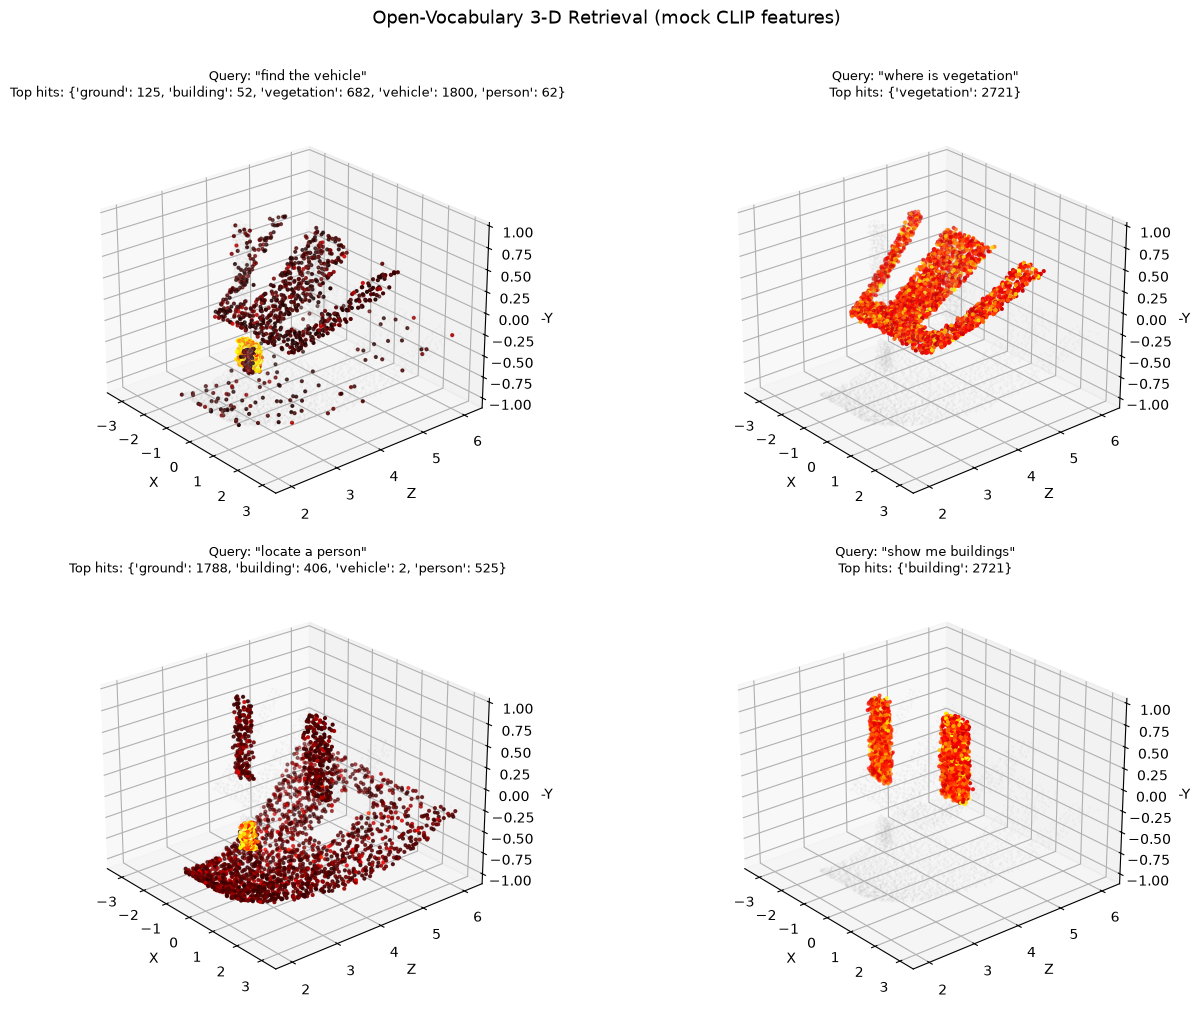


For each query the top-5 % of points (by cosine similarity) are highlighted.
In a real system, CLIP text/image encoders replace the mock embeddings.


In [8]:
# -- 4.9  Demo: open-vocabulary retrieval on a semantic point cloud --
#
# We simulate the open-vocabulary pipeline:
#   1. Start from our semantic point cloud (xyz + class labels).
#   2. Assign each point a mock "CLIP feature" based on its class.
#   3. Define text queries as mock "text embeddings".
#   4. Retrieve points via cosine similarity — just as LERF / OpenScene would.

np.random.seed(42)

FEATURE_DIM = 64

# Step 1: define a mock "CLIP embedding" centroid per class.
# In reality these come from CLIP's image encoder; here we use random
# unit vectors with controlled inter-class separation.
class_centroids = np.random.randn(NUM_CLASSES, FEATURE_DIM)
class_centroids /= np.linalg.norm(class_centroids, axis=1, keepdims=True)

# Step 2: assign each point a noisy version of its class centroid.
point_features = class_centroids[labels_flat] + np.random.randn(len(labels_flat), FEATURE_DIM) * 0.15
point_features /= np.linalg.norm(point_features, axis=1, keepdims=True)

# Step 3: simulate text queries.
# A real system would run CLIP's text encoder; here we craft query
# vectors close to the class centroids with some noise.
text_queries = {
    "find the vehicle":     class_centroids[4] + np.random.randn(FEATURE_DIM) * 0.05,
    "where is vegetation":  class_centroids[2] + np.random.randn(FEATURE_DIM) * 0.05,
    "locate a person":      class_centroids[5] + np.random.randn(FEATURE_DIM) * 0.05,
    "show me buildings":    class_centroids[1] + np.random.randn(FEATURE_DIM) * 0.05,
}
for q in text_queries:
    text_queries[q] /= np.linalg.norm(text_queries[q])

# Step 4: cosine similarity retrieval.
print("Open-vocabulary 3-D retrieval results")
print("=" * 55)

fig, axes = plt.subplots(2, 2, figsize=(14, 10),
                         subplot_kw={"projection": "3d"})
step = max(1, len(xyz) // 5000)

for ax, (query_text, query_vec) in zip(axes.flat, text_queries.items()):
    similarities = point_features @ query_vec
    threshold = np.percentile(similarities, 95)
    hit_mask = similarities >= threshold

    actual_classes = labels_flat[hit_mask]
    class_counts = {CLASS_NAMES[k]: int(np.sum(actual_classes == k))
                    for k in range(NUM_CLASSES) if np.sum(actual_classes == k) > 0}

    bg_alpha = 0.08
    bg_color = np.full((len(xyz[::step]), 4), [0.7, 0.7, 0.7, bg_alpha])
    ax.scatter(xyz[::step, 0], xyz[::step, 2], -xyz[::step, 1],
               c=bg_color, s=0.5)

    hit_xyz = xyz[hit_mask]
    hit_sim = similarities[hit_mask]
    h_step = max(1, len(hit_xyz) // 2000)
    sc = ax.scatter(hit_xyz[::h_step, 0], hit_xyz[::h_step, 2],
                    -hit_xyz[::h_step, 1],
                    c=hit_sim[::h_step], cmap="hot", s=4, vmin=threshold * 0.9)

    ax.set_xlabel("X"); ax.set_ylabel("Z"); ax.set_zlabel("-Y")
    ax.set_title(f'Query: "{query_text}"\nTop hits: {class_counts}', fontsize=9)
    ax.view_init(elev=25, azim=-40)

plt.suptitle("Open-Vocabulary 3-D Retrieval (mock CLIP features)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("\nFor each query the top-5 % of points (by cosine similarity) are highlighted.")
print("In a real system, CLIP text/image encoders replace the mock embeddings.")

---
## 5  Multi-Camera / BEV Perception (Discussion)

Autonomous vehicles typically use 6-8 surround-view cameras.  Rather
than running per-camera detection and merging post hoc, recent methods
lift all camera features into a **Bird's-Eye View (BEV)** representation
and reason in 3-D directly.

### 5.1  LSS -- Lift, Splat, Shoot (Philion & Fidler, 2020)

**Lift.** For every pixel $(u, v)$ and a set of $D$ depth hypotheses
$\{d_1, \dots, d_D\}$, the network predicts a categorical depth
distribution:

$$
\alpha_d = \text{softmax}(\mathbf{f}_{\text{depth}})_d,
\qquad d \in \{d_1, \ldots, d_D\}
$$

where $\mathbf{f}_{\text{depth}} \in \mathbb{R}^D$ is the depth logit
vector at pixel $(u,v)$.  Simultaneously a context feature
$\mathbf{f}_{u,v} \in \mathbb{R}^C$ is produced.

The *lifted* feature at each depth bin is the outer product:

$$
\mathbf{c}_{u,v,d} = \alpha_d \cdot \mathbf{f}_{u,v}
    \quad \in \mathbb{R}^C
$$

This creates a pseudo-point cloud of features along each camera ray,
weighted by the predicted depth probability.

**Splat.** All lifted features from all cameras are projected into a
common BEV grid using known camera extrinsics.  Features landing in the
same BEV pillar are summed (or averaged).

**Shoot.** The resulting BEV feature map feeds standard 2-D
convolutional heads for downstream tasks: driveable-area segmentation,
lane detection, object detection, motion planning.

### 5.2  BEVFormer (Li et al., 2022)

BEVFormer replaces the explicit depth prediction with **spatial
cross-attention**.  Each BEV query attends to image features from
multiple cameras using *deformable attention* (Zhu et al., 2021):

$$
\text{DeformAttn}(\mathbf{q}, \mathbf{p}, \mathbf{x})
= \sum_{m=1}^{M} W_m
  \biggl[
    \sum_{j=1}^{J} A_{mj} \cdot W'_m \,
    \mathbf{x}\!\bigl(\mathbf{p} + \Delta\mathbf{p}_{mj}\bigr)
  \biggr]
$$

where $\mathbf{q}$ is the BEV query, $\mathbf{p}$ is the reference
point projected into each camera view, $\Delta\mathbf{p}_{mj}$ are
learned offsets, $A_{mj}$ are attention weights, and $M$, $J$ are
the numbers of attention heads and sampling points.

BEVFormer also uses **temporal self-attention**: BEV queries at time
$t$ attend to the BEV features from $t-1$, enabling temporal
reasoning without explicit tracking.

---
## 6  Panoptic Mapping (Discussion)

### 6.1  From semantic to panoptic segmentation

Semantic segmentation assigns a class label to every pixel but does not
distinguish individual *instances* of the same class.  **Panoptic
segmentation** (Kirillov et al., 2019) unifies:

* **Stuff** -- amorphous regions (road, sky, vegetation) where instance
  identity is meaningless.
* **Things** -- countable objects (cars, people, bicycles) where each
  instance gets a unique ID.

The output is a pair $(\text{class}_k, \text{instance\_id})$ for every
pixel.

### 6.2  Panoptic Quality (PQ)

PQ elegantly decomposes into two factors: **Segmentation Quality (SQ)**
and **Recognition Quality (RQ)**.  Let TP, FP, FN denote the numbers of
true-positive, false-positive, and false-negative segment matches
(a predicted segment matches a ground-truth segment if their IoU
exceeds 0.5).

$$
\text{PQ}
= \underbrace{\frac{\displaystyle\sum_{(p,g)\in\text{TP}} \text{IoU}(p,g)}
              {|\text{TP}|}}_{\text{SQ (Segmentation Quality)}}
  \;\times\;
  \underbrace{\frac{|\text{TP}|}
              {|\text{TP}| + \tfrac{1}{2}|\text{FP}|
                           + \tfrac{1}{2}|\text{FN}|}}_{\text{RQ (Recognition Quality)}}
$$

* **SQ** measures the average overlap quality of matched segments
  (always between 0.5 and 1.0 by the matching criterion).
* **RQ** is essentially the $F_1$ score over segment matches.

PQ is computed separately for stuff and things classes, then averaged.

### 6.3  Panoptic 3-D mapping

Extending the ideas of Sections 2-3 to panoptic mapping requires:

1. **Instance tracking** across frames -- linking the same car seen from
   two viewpoints.
2. **Per-instance reconstruction** -- maintaining a separate volumetric
   or surfel model for each *thing* instance.
3. **Stuff fusion** -- standard semantic TSDF for background classes.

Systems like Panoptic Multi-TSDFs (Schmid et al., 2022) and Panoptic
Neural Fields (Kundu et al., 2022) realise this architecture.

---
## 6b  3-D Scene Graphs

### Motivation

A point cloud or voxel map encodes *where* things are but not *how they
relate*.  **3-D scene graphs** add a layer of structured, relational
reasoning on top of metric maps.

### 6b.1  Representation

A 3-D scene graph is a **directed attributed graph** $\mathcal{G} = (\mathcal{V}, \mathcal{E})$:

* **Nodes** $v \in \mathcal{V}$: objects or regions, each annotated
  with attributes (class label, bounding box, centroid, colour,
  CLIP embedding, …).
* **Edges** $(v_i, v_j) \in \mathcal{E}$: spatial or semantic
  relationships — e.g. `chair ON floor`, `table NEXT_TO wall`,
  `lamp ABOVE desk`.

Common relationship types:

| Relation | Meaning |
|----------|---------|
| `ON` | Resting on / supported by |
| `NEXT_TO` | Within a proximity threshold |
| `ABOVE` / `BELOW` | Vertical spatial relation |
| `INSIDE` | Containment |
| `PART_OF` | Part-whole hierarchy |

### 6b.2  Hierarchical scene graphs

Real-world scenes are naturally **hierarchical**:

$$
\text{Building} \;\to\; \text{Room} \;\to\; \text{Objects}
\;\to\; \text{Parts}
$$

The graph captures this via `PART_OF` / `CONTAINS` edges between
levels.  A query like *"which room has a red chair?"* traverses the
hierarchy: find nodes with class `chair` and attribute `red`, then
follow `INSIDE` edges upward to the room node.

Hydra (Hughes et al., 2022) builds such hierarchical 3-D scene
graphs in real time from a robot's SLAM system, organising the world
into layers: metric mesh → objects → places → rooms → building.

### 6b.3  Applications

* **Language-guided navigation:** A robot can plan over the graph
  rather than raw geometry — *"go to the table next to the window"*
  resolves to a graph query.
* **Task planning:** An LLM can reason over the scene graph to
  generate manipulation plans — knowing that a mug is `ON` a table
  and the table is `IN` the kitchen.
* **Change detection:** Comparing scene graphs from two time steps
  reveals structural changes (objects moved, added, removed).
* **Multi-agent coordination:** Agents share compact scene graphs
  instead of raw point clouds, reducing communication bandwidth.

3-D Scene Graph
Nodes: 8  |  Edges: 15

Nodes:
  [0] floor         centroid=(+0.0, -1.5, +3.0)
  [1] wall          centroid=(-2.8, +0.0, +3.0)
  [2] table         centroid=(+0.5, -0.8, +2.5)
  [3] chair         centroid=(+0.5, -1.0, +1.5)
  [4] laptop        centroid=(+0.5, -0.3, +2.5)
  [5] mug           centroid=(+0.9, -0.3, +2.4)
  [6] bookshelf     centroid=(-2.5, -0.2, +4.0)
  [7] room          centroid=(+0.0, +0.0, +3.0)

Edges (relationships):
  table        --[   ON   ]--> floor
  table        --[NEXT_TO ]--> laptop
  table        --[NEXT_TO ]--> mug
  chair        --[   ON   ]--> floor
  laptop       --[   ON   ]--> table
  laptop       --[NEXT_TO ]--> mug
  mug          --[   ON   ]--> table
  bookshelf    --[   ON   ]--> floor
  floor        --[ INSIDE ]--> room
  wall         --[ INSIDE ]--> room
  table        --[ INSIDE ]--> room
  chair        --[ INSIDE ]--> room
  laptop       --[ INSIDE ]--> room
  mug          --[ INSIDE ]--> room
  bookshelf    --[ INSIDE ]--> room


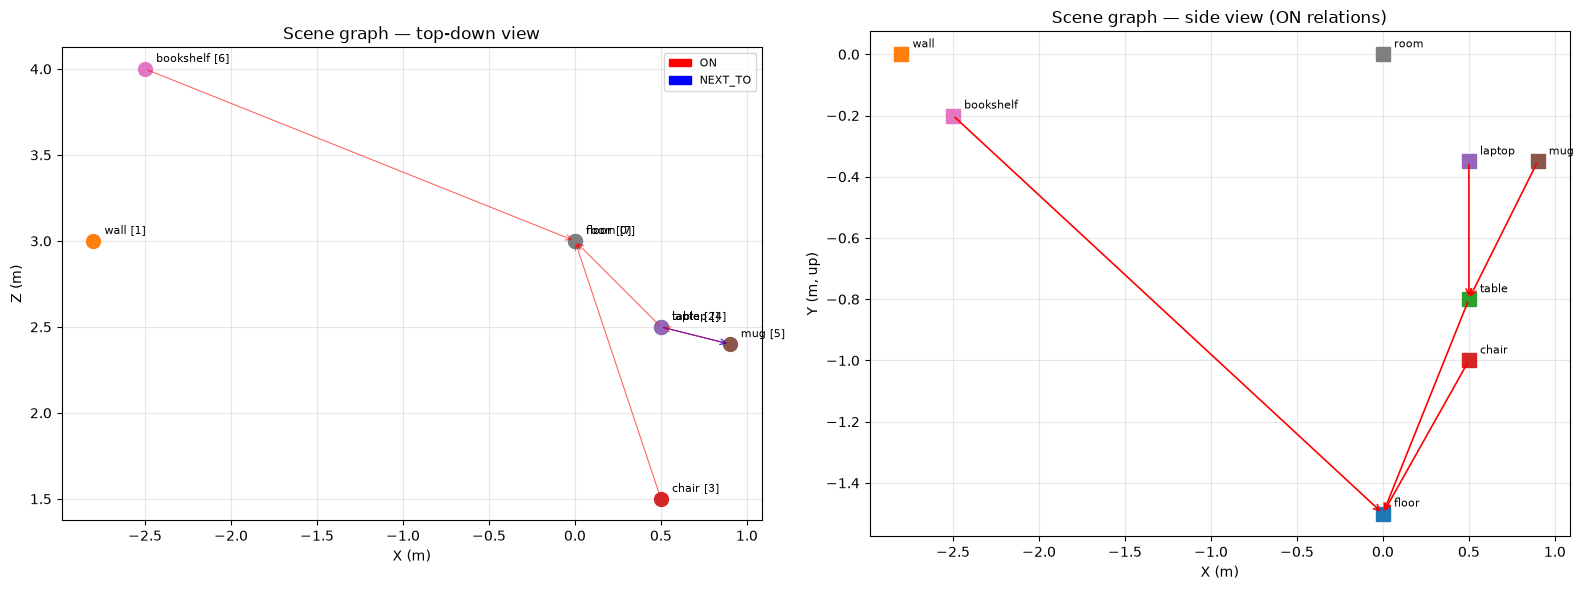


Graph queries:
--------------------------------------------------
  "laptop" is ON "table"
  "mug" is ON "table"
  "chair" is ON "floor"
  "table" is NEXT_TO: ['laptop', 'mug']


In [9]:
# -- 6b.4  Demo: build a simple 3-D scene graph from detected objects --

# Simulated object detections (as if from a panoptic 3-D map).
detected_objects = [
    {"id": 0, "label": "floor",     "centroid": [0.0, -1.5, 3.0], "bbox_size": [6.0, 0.1, 6.0]},
    {"id": 1, "label": "wall",      "centroid": [-2.8, 0.0, 3.0], "bbox_size": [0.1, 3.0, 6.0]},
    {"id": 2, "label": "table",     "centroid": [0.5, -0.8, 2.5], "bbox_size": [1.2, 0.8, 0.8]},
    {"id": 3, "label": "chair",     "centroid": [0.5, -1.0, 1.5], "bbox_size": [0.5, 1.0, 0.5]},
    {"id": 4, "label": "laptop",    "centroid": [0.5, -0.35, 2.5],"bbox_size": [0.4, 0.05, 0.3]},
    {"id": 5, "label": "mug",       "centroid": [0.9, -0.35, 2.4],"bbox_size": [0.1, 0.12, 0.1]},
    {"id": 6, "label": "bookshelf", "centroid": [-2.5, -0.2, 4.0],"bbox_size": [0.4, 2.0, 1.5]},
    {"id": 7, "label": "room",      "centroid": [0.0, 0.0, 3.0],  "bbox_size": [6.0, 3.0, 6.0]},
]

# --- Heuristic relationship inference ---

PROXIMITY_THRESH = 1.0
VERTICAL_SUPPORT_THRESH = 0.3

def infer_relationships(objects):
    """Infer spatial relationships from object centroids and bounding boxes."""
    edges = []
    obj_map = {o["id"]: o for o in objects}

    for a in objects:
        if a["label"] == "room":
            continue
        for b in objects:
            if a["id"] == b["id"]:
                continue

            ca = np.array(a["centroid"])
            cb = np.array(b["centroid"])
            horiz_dist = np.sqrt((ca[0] - cb[0])**2 + (ca[2] - cb[2])**2)
            vert_diff = ca[1] - cb[1]

            sa = np.array(a["bbox_size"])
            sb = np.array(b["bbox_size"])

            # ON: a is slightly above b, b is a plausible support surface
            if (0 < vert_diff < (sb[1]/2 + sa[1]/2 + VERTICAL_SUPPORT_THRESH)
                    and horiz_dist < max(sb[0], sb[2]) / 2 + 0.3
                    and a["label"] not in ("floor", "wall", "room")
                    and b["label"] not in ("wall", "room")):
                edges.append((a["id"], b["id"], "ON"))

            # NEXT_TO: close horizontally, similar height
            if (horiz_dist < PROXIMITY_THRESH
                    and abs(vert_diff) < 0.5
                    and a["id"] < b["id"]
                    and a["label"] not in ("floor", "room")
                    and b["label"] not in ("floor", "room")):
                edges.append((a["id"], b["id"], "NEXT_TO"))

    # INSIDE room
    room = obj_map.get(7)
    if room:
        for o in objects:
            if o["id"] != room["id"]:
                edges.append((o["id"], room["id"], "INSIDE"))

    return edges

edges = infer_relationships(detected_objects)

print("3-D Scene Graph")
print("=" * 50)
print(f"Nodes: {len(detected_objects)}  |  Edges: {len(edges)}")
print()
print("Nodes:")
for o in detected_objects:
    cx, cy, cz = o["centroid"]
    print(f"  [{o['id']}] {o['label']:12s}  centroid=({cx:+.1f}, {cy:+.1f}, {cz:+.1f})")
print()
print("Edges (relationships):")
obj_name = {o["id"]: o["label"] for o in detected_objects}
for src, dst, rel in edges:
    print(f"  {obj_name[src]:12s} --[{rel:^8s}]--> {obj_name[dst]}")

# --- Visualise the scene graph ---

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: top-down 2-D layout of object centroids
ax = axes[0]
for o in detected_objects:
    cx, cz = o["centroid"][0], o["centroid"][2]
    ax.plot(cx, cz, "o", markersize=10)
    ax.annotate(f'{o["label"]} [{o["id"]}]', (cx, cz),
                textcoords="offset points", xytext=(8, 5), fontsize=8)
for src, dst, rel in edges:
    if rel in ("ON", "NEXT_TO"):
        cs = detected_objects[src]["centroid"]
        cd = detected_objects[dst]["centroid"]
        ax.annotate("", xy=(cd[0], cd[2]), xytext=(cs[0], cs[2]),
                     arrowprops=dict(arrowstyle="->", lw=0.8,
                                     color="red" if rel == "ON" else "blue",
                                     alpha=0.6))
ax.set_xlabel("X (m)"); ax.set_ylabel("Z (m)")
ax.set_title("Scene graph — top-down view")
ax.legend(handles=[
    mpatches.Patch(color="red", label="ON"),
    mpatches.Patch(color="blue", label="NEXT_TO"),
], fontsize=8)
ax.set_aspect("equal"); ax.grid(True, alpha=0.3)

# Right: side view (X vs Y)
ax2 = axes[1]
for o in detected_objects:
    cx, cy = o["centroid"][0], o["centroid"][1]
    ax2.plot(cx, cy, "s", markersize=10)
    ax2.annotate(f'{o["label"]}', (cx, cy),
                 textcoords="offset points", xytext=(8, 5), fontsize=8)
for src, dst, rel in edges:
    if rel == "ON":
        cs = detected_objects[src]["centroid"]
        cd = detected_objects[dst]["centroid"]
        ax2.annotate("", xy=(cd[0], cd[1]), xytext=(cs[0], cs[1]),
                      arrowprops=dict(arrowstyle="->", lw=1.2, color="red"))
ax2.set_xlabel("X (m)"); ax2.set_ylabel("Y (m, up)")
ax2.set_title("Scene graph — side view (ON relations)")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Query the scene graph ---

print("\nGraph queries:")
print("-" * 50)

def query_on(target_label, edges, obj_map):
    """Find what the target object is ON."""
    for src, dst, rel in edges:
        if rel == "ON" and obj_map[src]["label"] == target_label:
            return obj_map[dst]["label"]
    return None

for item in ["laptop", "mug", "chair"]:
    support = query_on(item, edges, {o["id"]: o for o in detected_objects})
    if support:
        print(f'  "{item}" is ON "{support}"')

def query_next_to(target_label, edges, obj_map):
    """Find objects next to the target."""
    neighbours = []
    for src, dst, rel in edges:
        if rel == "NEXT_TO":
            if obj_map[src]["label"] == target_label:
                neighbours.append(obj_map[dst]["label"])
            elif obj_map[dst]["label"] == target_label:
                neighbours.append(obj_map[src]["label"])
    return neighbours

for item in ["table", "bookshelf"]:
    nbrs = query_next_to(item, edges, {o["id"]: o for o in detected_objects})
    if nbrs:
        print(f'  "{item}" is NEXT_TO: {nbrs}')

---
## 7  Exercises

### Exercise 7.1 -- Segment a complex synthetic scene

Generate a more complex synthetic scene with multiple overlapping objects.
Apply Sobel edge detection combined with colour thresholding to segment
the scene.  Compute the per-class IoU against the known ground truth.

Per-class IoU:
  ground      : 1.0000
  building    : 1.0000
  vegetation  : 1.0000
  sky         : 1.0000
  vehicle     : 1.0000
  person      : 1.0000
  mIoU        : 1.0000


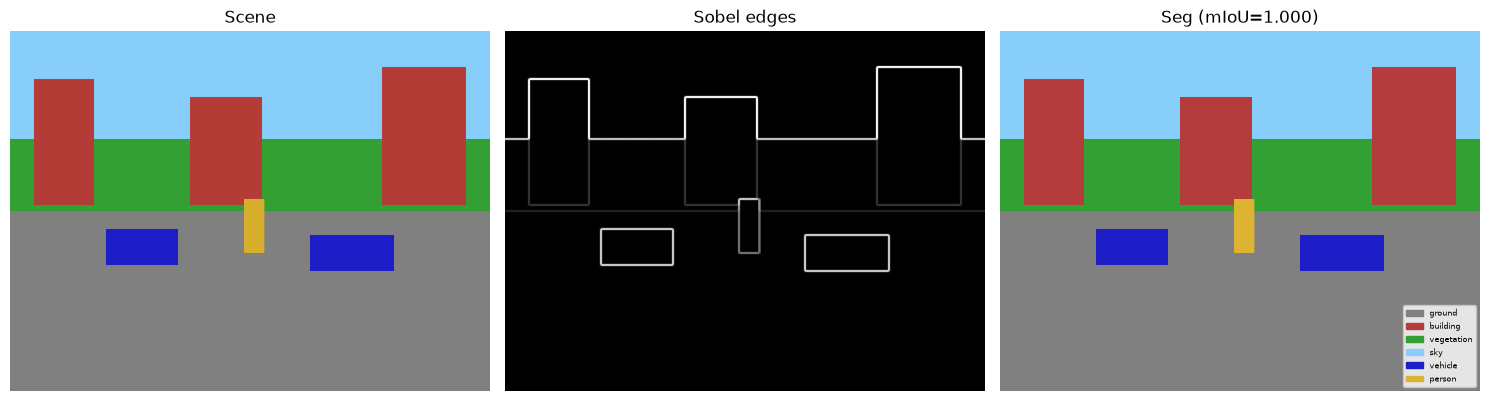

In [10]:
# -- Exercise 7.1: Segment a complex synthetic scene --
# Uses: CLASS_NAMES, NUM_CLASSES, CLASS_COLORS, simple_segment (from cells 3-4)
import cv2

H1, W1 = 300, 400
sky_h, veg_h = int(0.30 * H1), int(0.50 * H1)

# --- Synthetic scene with ground-truth labels (provided) ---
scene = np.zeros((H1, W1, 3), dtype=np.uint8)
gt_labels = np.zeros((H1, W1), dtype=np.int32)
scene[:sky_h] = [135, 206, 250];                       gt_labels[:sky_h] = 3       # sky
scene[sky_h:veg_h] = [50, 160, 50];                    gt_labels[sky_h:veg_h] = 2  # vegetation
scene[veg_h:] = [128, 128, 128];                       gt_labels[veg_h:] = 0       # ground
buildings = [(max(sky_h-50,0), veg_h-5, 20, 70),
             (max(sky_h-35,0), veg_h-5, 150, 210),
             (max(sky_h-60,0), veg_h-5, 310, 380)]
vehicles = [(veg_h+15, veg_h+45, 80, 140), (veg_h+20, veg_h+50, 250, 320)]
for r0, r1, c0, c1 in buildings:
    scene[r0:r1, c0:c1] = [180, 60, 55];  gt_labels[r0:r1, c0:c1] = 1
for r0, r1, c0, c1 in vehicles:
    scene[r0:r1, c0:c1] = [30, 30, 200];  gt_labels[r0:r1, c0:c1] = 4
scene[veg_h-10:veg_h+35, 195:212] = [215, 175, 45]
gt_labels[veg_h-10:veg_h+35, 195:212] = 5  # person

def compute_iou(pred, gt, num_classes):
    """Return a list of per-class IoU values."""
    ious = []
    for k in range(num_classes):
        inter = np.sum((pred == k) & (gt == k))
        union = np.sum((pred == k) | (gt == k))
        ious.append(inter / union if union > 0 else float("nan"))
    return ious

gray = cv2.cvtColor(scene, cv2.COLOR_RGB2GRAY)
sobel_x = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
edges_mag = np.sqrt(sobel_x**2 + sobel_y**2)
edges_norm = np.clip(edges_mag / edges_mag.max() * 255, 0, 255).astype(np.uint8)

pred_labels = simple_segment(scene, sky_h, veg_h)

ious = compute_iou(pred_labels, gt_labels, NUM_CLASSES)
miou = np.nanmean(ious)
print("Per-class IoU:")
for i, (name, v) in enumerate(zip(CLASS_NAMES, ious)):
    print(f"  {name:12s}: {v:.4f}")
print(f"  {'mIoU':12s}: {miou:.4f}")
if not (miou > 0.5):
    print("⚠ " + f"mIoU too low ({miou:.3f}) -- check your segmentation")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].imshow(scene);                    axes[0].set_title("Scene");              axes[0].axis("off")
axes[1].imshow(edges_norm, cmap="gray");  axes[1].set_title("Sobel edges");        axes[1].axis("off")
axes[2].imshow(CLASS_COLORS[pred_labels]); axes[2].set_title(f"Seg (mIoU={miou:.3f})"); axes[2].axis("off")
patches = [mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
axes[2].legend(handles=patches, loc="lower right", fontsize=6)
plt.tight_layout(); plt.show()

### Exercise 7.2 -- Lift labels to a point cloud

Use a new synthetic depth map and the label map from Exercise 7.1.
Back-project to a semantic point cloud.  Visualise and count points per
class.

Point cloud: 106439 points
  ground      :   55505 points
  building    :   18625 points
  vegetation  :   14005 points
  sky         :   13639 points
  vehicle     :    3900 points
  person      :     765 points


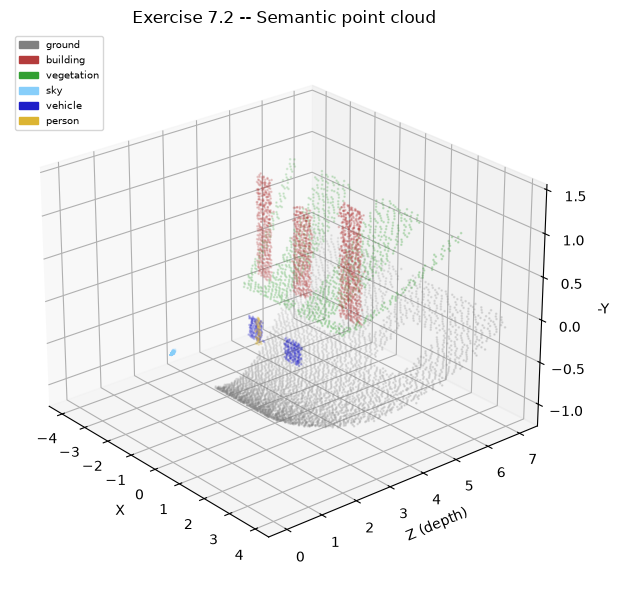

In [11]:
# -- Exercise 7.2: Lift labels to a point cloud --
# Uses: depth_to_pointcloud (cell 1 import)
# Uses: H1, W1, sky_h, veg_h, buildings, vehicles, gt_labels, scene (from 7.1)

# --- Synthetic depth map (sky = 0 means no valid depth) ---
depth2 = np.zeros((H1, W1), dtype=np.float64)
for r in range(sky_h, veg_h):
    t = (r - sky_h) / max(veg_h - sky_h, 1)
    depth2[r, :] = 6.0 - 2.5 * t           # vegetation: 3.5-6 m
for r in range(veg_h, H1):
    t = (r - veg_h) / max(H1 - veg_h, 1)
    depth2[r, :] = 7.0 - 5.0 * t           # ground: 2-7 m
for r0, r1, c0, c1 in buildings:
    depth2[max(r0, 0):r1, c0:c1] = 4.0
for r0, r1, c0, c1 in vehicles:
    depth2[r0:r1, c0:c1] = 3.0
depth2[veg_h - 10:veg_h + 35, 195:212] = 2.5  # person
depth2 += np.random.normal(0, 0.03, depth2.shape)
depth2 = np.clip(depth2, 0, None)

cam2 = CameraIntrinsics(fx=350.0, fy=350.0, cx=W1 / 2, cy=H1 / 2)
K2 = cam2.K

pts2 = depth_to_pointcloud(depth2, K2, color=scene)
xyz2 = pts2[:, :3]

valid2 = depth2 > 0
labels2_flat = gt_labels[valid2]

assert xyz2.shape[0] > 0, "Point cloud must be non-empty"
assert len(labels2_flat) == xyz2.shape[0], "Label count must match point count"
print(f"Point cloud: {xyz2.shape[0]} points")
for k in range(NUM_CLASSES):
    count = int(np.sum(labels2_flat == k))
    print(f"  {CLASS_NAMES[k]:12s}: {count:>7d} points")

if not (xyz2.shape[0] > 0):
    print("⚠ " + "Point cloud is empty -- did you call depth_to_pointcloud?")
if not (len(labels2_flat) == xyz2.shape[0]):
    print("⚠ " + "Label count must match point count")

# --- 3D semantic point cloud visualization ---
colors2 = CLASS_COLORS[labels2_flat] / 255.0 if len(labels2_flat) > 0 else np.zeros((0, 3))
step2 = max(1, len(xyz2) // 8000)
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection="3d")
if len(xyz2) > 0:
    ax.scatter(xyz2[::step2, 0], xyz2[::step2, 2], -xyz2[::step2, 1],
               c=colors2[::step2], s=0.8, alpha=0.5)
ax.set_xlabel("X"); ax.set_ylabel("Z (depth)"); ax.set_zlabel("-Y")
ax.set_title("Exercise 7.2 -- Semantic point cloud")
ax.view_init(elev=25, azim=-40)
patches = [mpatches.Patch(color=CLASS_COLORS[i]/255.0, label=CLASS_NAMES[i]) for i in range(NUM_CLASSES)]
ax.legend(handles=patches, loc="upper left", fontsize=7)
plt.tight_layout(); plt.show()

### Exercise 7.3 -- Fuse labels across multiple views in Semantic TSDF

Generate 8 synthetic frames from a circular camera trajectory.
Integrate all frames into a `SemanticTSDF` volume.  Measure per-voxel
entropy as a function of the number of integrated frames to show that
label confidence increases with more observations.

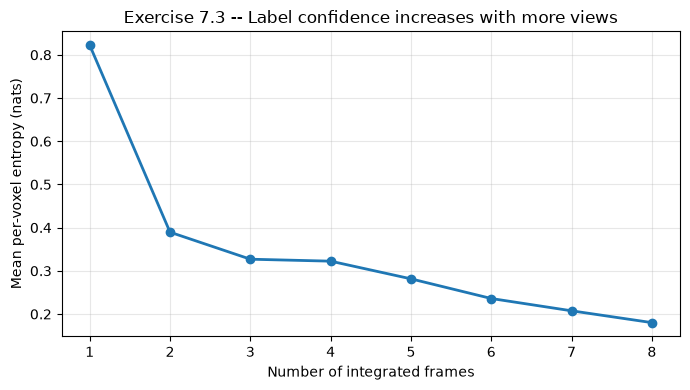


Entropy after 1 frame:  0.8223
Entropy after 8 frames: 0.1801
Reduction:             0.6422


In [12]:
# -- Exercise 7.3: Fuse labels across views in Semantic TSDF --
# Uses: SemanticTSDF (cell 1 import), K2, depth2, gt_labels (from 7.1/7.2)

from src.semantic import SemanticTSDF

vol_bounds3 = np.array([[-4.0, 4.0],
                         [-3.0, 3.0],
                         [ 0.5, 8.0]])

sem_tsdf3 = SemanticTSDF(
    vol_bounds=vol_bounds3, voxel_size=0.20,
    num_classes=NUM_CLASSES, trunc_dist=0.60,
)

n_frames = 8
radius = 0.5
angles = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)
entropies_per_frame = []

for fi in range(n_frames):
    angle = angles[fi]
    tx = radius * np.cos(angle)
    tz = radius * np.sin(angle)
    T_c2w = np.eye(4)
    T_c2w[0, 3] = tx
    T_c2w[2, 3] = tz

    depth_fi = np.where(depth2 > 0, depth2 + np.random.normal(0, 0.05, depth2.shape), 0.0)
    depth_fi = np.clip(depth_fi, 0, None)

    label_noise = gt_labels.copy()
    flip_mask = np.random.rand(*gt_labels.shape) < 0.03
    label_noise[flip_mask] = np.random.randint(0, NUM_CLASSES, size=int(flip_mask.sum()))

    sem_tsdf3.integrate(depth=depth_fi, K=K2, T=T_c2w, labels=label_noise)

    probs = sem_tsdf3.get_class_probabilities()
    observed = sem_tsdf3._weight > 0
    ent = -np.sum(probs[observed] * np.log(probs[observed] + 1e-12), axis=-1)
    entropies_per_frame.append(ent.mean())

if not (len(entropies_per_frame) == n_frames):
    print("⚠ " + "Should have one entropy value per frame")
assert entropies_per_frame[-1] <= entropies_per_frame[0] + 0.01,     "Entropy should decrease (or stay flat) as more views are fused"

# --- Plot entropy vs. frames ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, n_frames + 1), entropies_per_frame, "o-", linewidth=2)
ax.set_xlabel("Number of integrated frames")
ax.set_ylabel("Mean per-voxel entropy (nats)")
ax.set_title("Exercise 7.3 -- Label confidence increases with more views")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\nEntropy after 1 frame:  {entropies_per_frame[0]:.4f}")
print(f"Entropy after {n_frames} frames: {entropies_per_frame[-1]:.4f}")
print(f"Reduction:             {entropies_per_frame[0] - entropies_per_frame[-1]:.4f}")

### Exercise 7.4 -- Query the semantic map: *Where are the buildings?*

Given the fused Semantic TSDF, extract all voxels labelled as
*building* (class 1).  Compute the centroid and axis-aligned bounding
box of the building region.  Visualise the query result by highlighting
building voxels in the volume slice.

Building voxels found: 1706
Centroid (world): (0.04, -0.76, 3.38)
AABB min:         (-3.20, -1.60, 0.50)
AABB max:         (3.00, -0.20, 6.30)
AABB size:        (6.20, 1.40, 5.80) m


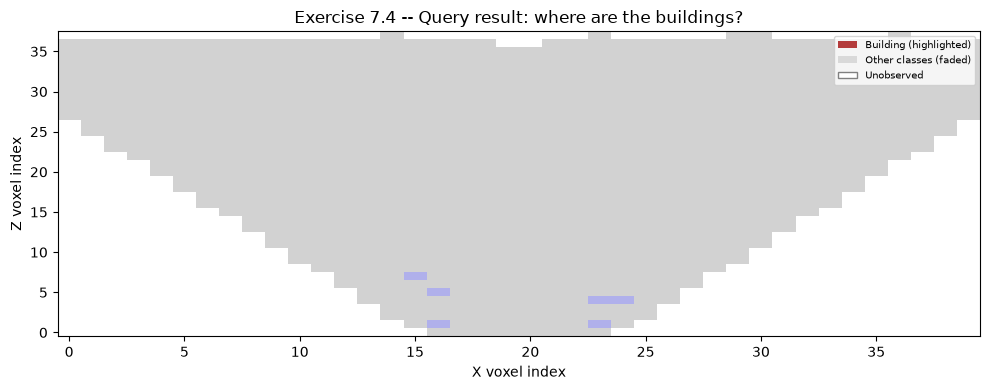

In [13]:
# -- Exercise 7.4: Query the semantic map --
# Uses: sem_tsdf3 (from 7.3), CLASS_COLORS, CLASS_NAMES, NUM_CLASSES

from matplotlib.patches import Patch

BUILDING_CLASS = 1

voxel_labels3 = sem_tsdf3.get_voxel_labels()
observed3 = sem_tsdf3._weight > 0

building_mask = (voxel_labels3 == BUILDING_CLASS) & observed3

bld_indices = np.argwhere(building_mask)
bld_world = bld_indices * sem_tsdf3.voxel_size + sem_tsdf3._origin
centroid = bld_world.mean(axis=0) if len(bld_world) > 0 else np.zeros(3)
bbox_min = bld_world.min(axis=0) if len(bld_world) > 0 else np.zeros(3)
bbox_max = bld_world.max(axis=0) if len(bld_world) > 0 else np.zeros(3)
building_count = int(building_mask.sum())

print(f"Building voxels found: {building_count}")
print(f"Centroid (world): ({centroid[0]:.2f}, {centroid[1]:.2f}, {centroid[2]:.2f})")
print(f"AABB min:         ({bbox_min[0]:.2f}, {bbox_min[1]:.2f}, {bbox_min[2]:.2f})")
print(f"AABB max:         ({bbox_max[0]:.2f}, {bbox_max[1]:.2f}, {bbox_max[2]:.2f})")
print(f"AABB size:        ({bbox_max[0]-bbox_min[0]:.2f}, "
      f"{bbox_max[1]-bbox_min[1]:.2f}, {bbox_max[2]-bbox_min[2]:.2f}) m")

if not (building_count > 0):
    print("⚠ " + "No building voxels found -- check your label extraction")

# --- Visualise: highlight buildings in a 2-D slice ---
y_mid3 = voxel_labels3.shape[1] // 2
sl_labels = voxel_labels3[:, y_mid3, :]
sl_weight = sem_tsdf3._weight[:, y_mid3, :]
sl_bld = building_mask[:, y_mid3, :]

vis = np.ones((*sl_labels.shape, 3), dtype=np.float64)
for k in range(NUM_CLASSES):
    m = (sl_labels == k) & (sl_weight > 0)
    vis[m] = CLASS_COLORS[k] / 255.0 * 0.35 + 0.65
vis[sl_bld] = CLASS_COLORS[BUILDING_CLASS] / 255.0

fig, ax = plt.subplots(figsize=(10, 4))
ax.imshow(vis.transpose(1, 0, 2), origin="lower", aspect="auto")
ax.set_xlabel("X voxel index"); ax.set_ylabel("Z voxel index")
ax.set_title("Exercise 7.4 -- Query result: where are the buildings?")
legend_elements = [
    Patch(facecolor=CLASS_COLORS[BUILDING_CLASS]/255.0, label="Building (highlighted)"),
    Patch(facecolor=[0.85, 0.85, 0.85], label="Other classes (faded)"),
    Patch(facecolor=[1.0, 1.0, 1.0], edgecolor="gray", label="Unobserved"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=7)
plt.tight_layout(); plt.show()

---

## Limitations & Failure Cases

- **Segmentation errors propagate to 3D:** A misclassified pixel becomes a persistently wrong label in the 3D map. Unlike geometric noise (which averages out over multiple views), semantic errors are systematic — if the 2D model confuses "road" and "sidewalk," every fused observation reinforces the mistake.
- **Class ambiguity at boundaries:** Edges between objects have uncertain labels in 2D segmentation, and back-projecting these boundary pixels into 3D spreads label noise across neighbouring voxels or points.
- **Open-set recognition:** Objects not in the training set are silently assigned the nearest known class. A fire hydrant may become a "bollard," or an unusual vehicle may be labelled "car." Open-vocabulary methods (LERF, OpenScene) mitigate this but still depend on the CLIP embedding space.
- **Temporal inconsistency:** Different frames may classify the same 3D surface differently due to viewpoint-dependent appearance, lighting changes, or partial occlusion. Without robust label fusion, the 3D map flickers between classes.
- **Label fusion voting limitations:** Majority voting — the simplest fusion strategy — can be wrong when most observations come from poor viewpoints (oblique angles, large distance) where segmentation confidence is low. Bayesian fusion with observation weighting helps but requires calibrated confidence scores.

## Summary

### Key Equations

| Concept | Formula |
|---------|---------|
| Semantic TSDF update | $\text{label}(v) = \arg\max_c \; \text{count}(c, v)$ (majority vote per voxel) |
| Log-odds label fusion | $\ell_c(v) \leftarrow \ell_c(v) + \log\frac{P(z \mid c)}{P(z \mid \neg c)}$ (log-likelihood ratio) |
| CLIP similarity | $\text{sim}(\mathbf{f}, \mathbf{t}) = \frac{\mathbf{f} \cdot \mathbf{t}}{\|\mathbf{f}\| \|\mathbf{t}\|}$ |
| BEV view transform | $\mathbf{V}_{3D}(x,y,z) = \sum_k \alpha_k(z) \, \mathbf{F}_{2D}^k(u,v)$ (LSS depth-weighted lifting) |

### Key Takeaways

- **Semantic segmentation** (SAM2, Mask2Former) assigns per-pixel labels; lifting to 3D
  requires depth + pose from earlier notebooks
- **Majority voting** is the simplest label fusion; Bayesian (log-odds) fusion handles
  noisy predictions more gracefully
- **Open-vocabulary 3D** (LERF, OpenScene, MPEC) uses CLIP/DINOv2 features distilled into
  3D representations, enabling text-based scene queries without fixed class lists
- **BEV perception** (LSS, BEVFormer) projects multi-camera features into a 3D voxel grid —
  the production approach used by Tesla and Waymo
- **Scene graphs** add relational structure on top of metric-semantic maps, enabling
  higher-level reasoning ("the mug is on the table next to the window")

### What's Next

Notebook 17 covers how to **evaluate** the quality of all these systems — trajectory accuracy,
depth error, reconstruction quality, and rendering fidelity.